# [PDF Loader](https://python.langchain.com/docs/integrations/document_loaders/#pdfs)

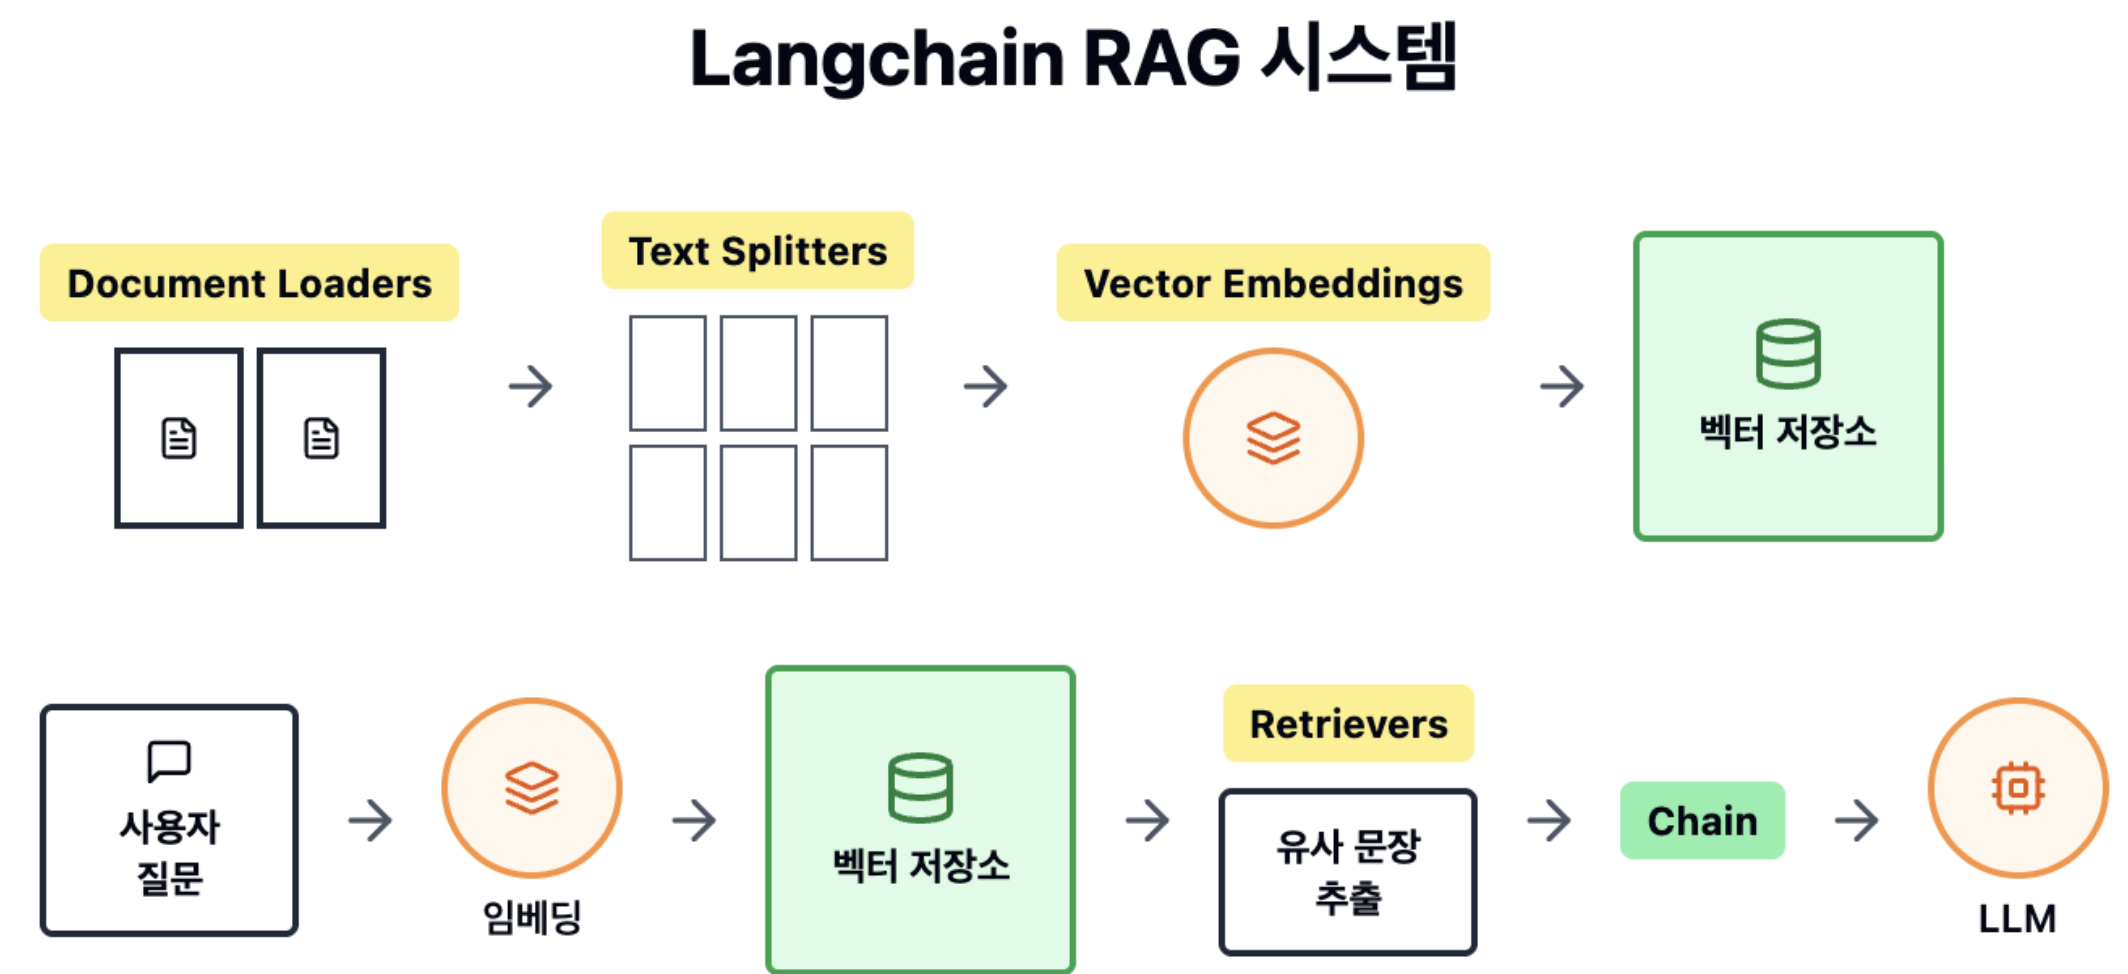

## PDF Loader가 중요한 이유
- RAG에서 PDF는 가장 흔한 데이터 소스 중 하나이며, PDF의 `텍스트 레이아웃`, `표 구조`, `이미지 포함 여부`에 따라 정확한 자료 추출 품질이 크게 달라진다.
- 따라서 문서 형태에 맞는 로더 선택은 `RAG 전체 품질을 좌우하는 핵심 요소`다.

## PDF Loader 3종 핵심 비교

### PyPDFLoader
- 가장 기본적인 텍스트 중심 PDF 로더
- 가볍고 빠르지만 기능 제한
- 단순 텍스트 문서에 적합


### PDFPlumberLoader
- 표(Table)와 레이아웃 분석에 최적화된 로더
- 테이블 추출 정확도 최고
- 형식이 있는 보고서나 논문에 강함

### PyMuPDF4LLMLoader
- 이미지·텍스트·구조를 가장 유연하게 처리하는 최신 로더
- 텍스트 + 이미지 + 구조까지 모두 지원
- PDF 내부 이미지(Blob) 완전 추출

## 상황별 로더 선택 가이드
| 상황            | 적합한 로더                |
| ------------- | --------------------- |
| 텍스트 기반 단순 PDF | **PyPDFLoader**       |
| 표 구조 중심 PDF   | **PDFPlumberLoader**  |
| 이미지·스캔 포함 PDF | **PyMuPDF4LLMLoader** |
| 가장 범용적인 로더    | **PyMuPDF4LLMLoader** |


## 추가 추천 PDF Loaders (LangChain 통합 대상)

| 로더 이름                          | 특징 및 장점 / 언제 쓰면 좋은가                                                                                                                                                         |
| ------------------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **UnstructuredPDFLoader**      | “텍스트 + 레이아웃 + 구조(단락, 리스트, 표 등)”를 좀 더 일반적인 방식으로 파싱해주는 로더. 단순 텍스트 추출보다는 구조를 살리고 싶을 때 유용. 복잡한 레이아웃의 PDF, 마크다운/HTML-like 출력이 필요한 경우 사용 추천. ([LangChain][1])                     |
| **PyPDFium2Loader**            | 백엔드로 `PyPDFium2` (PDFium) 라이브러리를 사용하는 로더. PDF를 렌더링 기반으로 처리하기 때문에, 렌더링된 페이지 이미지 기반 OCR 처리나 이미지 포함 PDF 처리 + 후처리에 유리. “텍스트 레이어가 불완전하거나 이미지 + 텍스트 혼합 PDF”에 유용. ([LangChain][1]) |
| **PDFMinerLoader**             | 전통적인 PDF 텍스트 추출 라이브러리인 `PDFMiner` 기반. 텍스트만 있는 PDF에서 최대한 원본의 텍스트 레이어를 파싱하고 싶을 때 적합. 레이아웃 단순한 리포트나 논문 같은 문서에 유리. ([LangChain][1])                                             |
| **MathPixPDFLoader**           | 수식(LaTeX, 이미지 내 수식 포함) PDF를 처리할 때 유용한 로더. 일반 PDF 로더가 수식이나 이미지 내 수식을 잘 처리하지 못할 경우, MathPix를 활용하면 수식 OCR/파싱이 가능 — 과학 논문, 수학 문서에 특히 적합. ([LangChain][1])                       |
| **Amazon Textract PDF Loader** | AWS 기반의 PDF 파싱 API를 사용하는 로더. 특히 스캔된 PDF, 이미지 기반 PDF, 구조가 복잡한 보고서 등에서 강함. 클라우드 API를 활용하므로 로컬 처리에 부담이 있을 때 — 또는 대량 PDF 처리가 필요할 때 유용. ([LangChain][1])                         |

[1]: https://python.langchain.com/docs/integrations/document_loaders/?utm_source=chatgpt.com "Document loaders | 🦜️🔗 LangChain"


# 예제

## PDF 파일들

In [1]:
pdf_attention = "data/Attention Is All You Need.pdf"
pdf_bert = "data/BERT.pdf"
pdf_lg_aimers = "data/LG Aimers 4기 소개자료.pdf"

## [예제: PyPDFLoader](https://python.langchain.com/docs/integrations/document_loaders/pypdfloader/)

### PyPDFLoader 파라미터 설명

| 파라미터 | 필수 여부 | 설명 | 예시 |
|---------|---------|------|------|
| `file_path` | 필수 | PDF 파일 경로 (로컬 파일 경로 또는 URL) | `"./document.pdf"` 또는 `"https://example.com/file.pdf"` |
| `extract_images` | 선택 | 이미지 추출 여부 (기본값: False) | `True` 또는 `False` |
| `password` | 선택 | 암호화된 PDF의 비밀번호 | `"mypassword123"` |

In [2]:
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader(
    file_path=pdf_lg_aimers,
    extract_images=False)

In [3]:
docs = loader.load()
print(f"PDF 파일의 페이지 수: {len(docs)}")

PDF 파일의 페이지 수: 7


### 메타정보 추출

In [4]:
docs[0].metadata

{'producer': 'PyPDF',
 'creator': 'PyPDF',
 'creationdate': '2025-07-15T07:40:32+00:00',
 'moddate': '2025-07-15T07:40:32+00:00',
 'source': 'data/LG Aimers 4기 소개자료.pdf',
 'total_pages': 7,
 'page': 0,
 'page_label': '1'}

### 텍스트 추출

In [5]:
print(docs[0].page_content)

LG AI연구원｜
LG Aimers 소개 자료


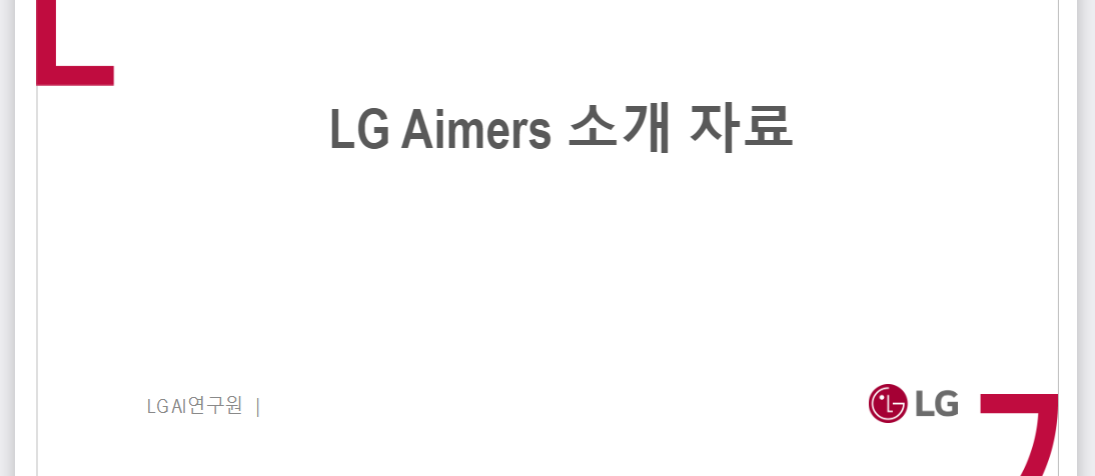

## [예제: pypdf](https://github.com/py-pdf/pypdf)

### 메타정보 추출

In [6]:
from pypdf import PdfReader

# PDF 파일 열기
reader = PdfReader(pdf_attention)

# 메타데이터 가져오기
metadata = reader.metadata

# 출력
print("PDF 메타데이터:")
for key, value in metadata.items():
    print(f"{key}: {value}")

PDF 메타데이터:
/Author: 
/CreationDate: D:20240410211143Z
/Creator: LaTeX with hyperref
/Keywords: 
/ModDate: D:20240410211143Z
/PTEX.Fullbanner: This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5
/Producer: pdfTeX-1.40.25
/Subject: 
/Title: 
/Trapped: /False


### 텍스트 추출

In [7]:
for i in reader.pages:
    print("="*50)
    # 페이지별 텍스트 추출 
    print(i.extract_text()[:300])
    break 

Provided proper attribution is provided, Google hereby grants permission to
reproduce the tables and figures in this paper solely for use in journalistic or
scholarly works.
Attention Is All You Need
Ashish Vaswani∗
Google Brain
avaswani@google.com
Noam Shazeer∗
Google Brain
noam@google.com
Niki Par


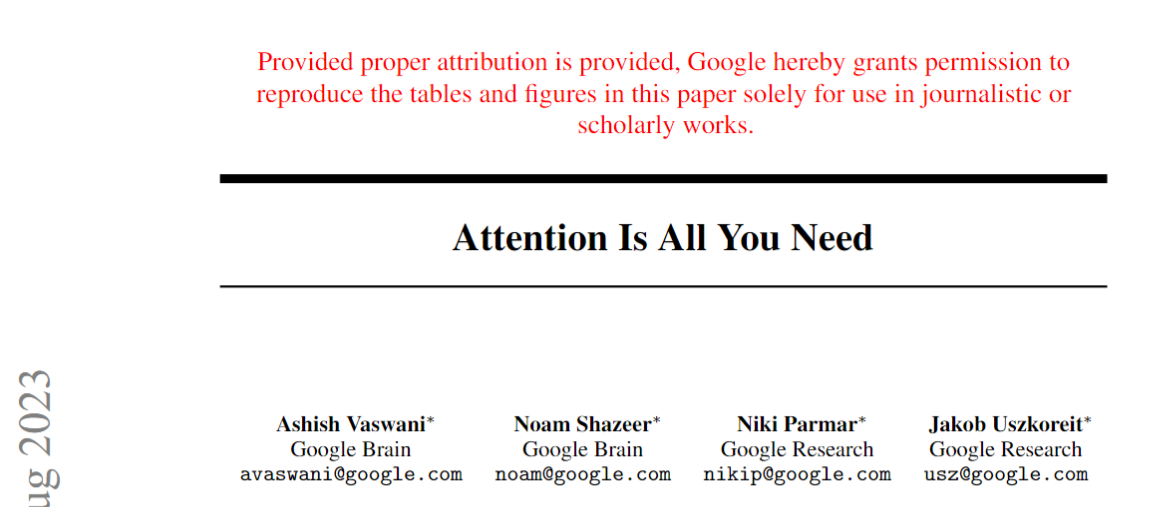

### with Langchain Document

In [8]:
from langchain_core.documents import Document

###########################################
# 초기화 
###########################################
dict_metadata = dict(reader.metadata)
documents = []
count = 0

###########################################
# 페이지별 처리  
###########################################
for i, page in enumerate(reader.pages):
    # 메타이데이터 추가 
    dict_metadata['page_no'] = i+1

    ###########################################
    # 페이지별 이미지 추가   
    ###########################################
    dict_metadata['lst_image_file_names'] = []
    for image_file_object in page.images:

        # Open and write the image data
        image_names = image_file_object.name.split(".")
        image_file_name = f"{image_names[0]}_{str(count)}.{image_names[1]}"
        with open(image_file_name, "wb") as fp:
            fp.write(image_file_object.data)
            count += 1
            dict_metadata['lst_image_file_names'].append(image_file_name)

    ###########################################
    # 페이지별 document 추가   
    ###########################################
    documents.append(Document(
        page_content=page.extract_text(),   # 페이지별 텍스트 
        metadata=dict_metadata              # 페이지별 메타데이터
    ))

> 추출된 이미지 및 메타데이터 확인 

In [9]:
documents[2].metadata

{'/Author': '',
 '/CreationDate': 'D:20240410211143Z',
 '/Creator': 'LaTeX with hyperref',
 '/Keywords': '',
 '/ModDate': 'D:20240410211143Z',
 '/PTEX.Fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5',
 '/Producer': 'pdfTeX-1.40.25',
 '/Subject': '',
 '/Title': '',
 '/Trapped': '/False',
 'page_no': 3,
 'lst_image_file_names': ['Im1_0.png']}

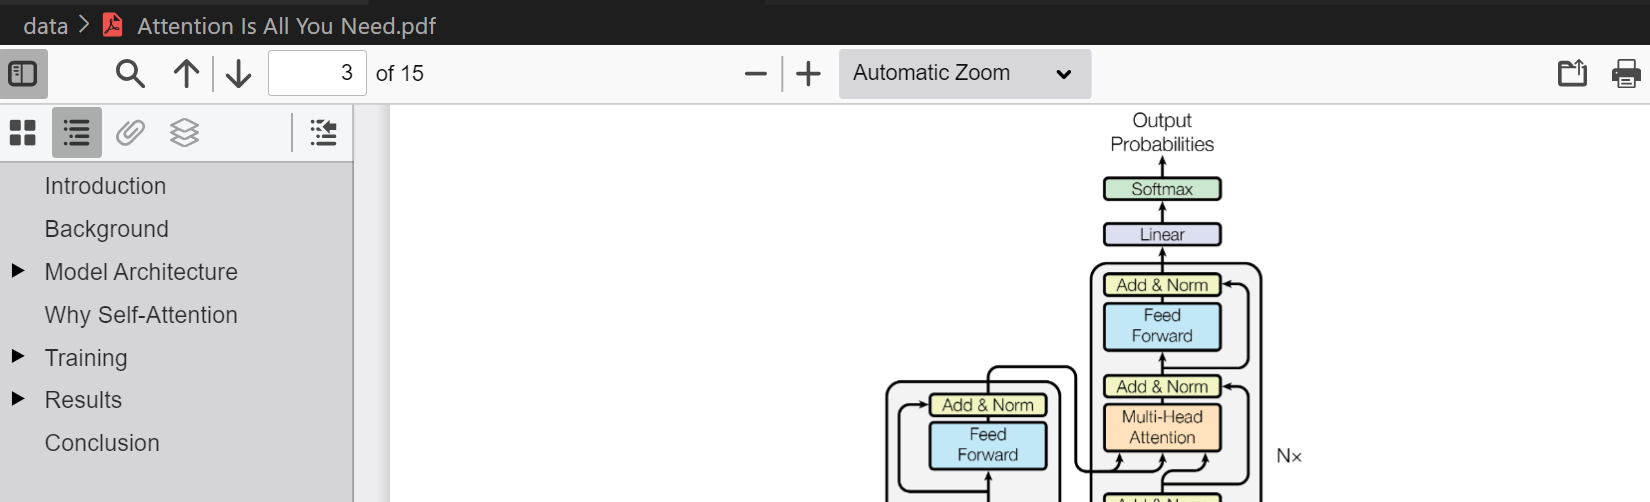

> 추출된 텍스트 확인 

In [10]:
print(documents[2].page_content[:300])

Figure 1: The Transformer - model architecture.
The Transformer follows this overall architecture using stacked self-attention and point-wise, fully
connected layers for both the encoder and decoder, shown in the left and right halves of Figure 1,
respectively.
3.1 Encoder and Decoder Stacks
Encoder


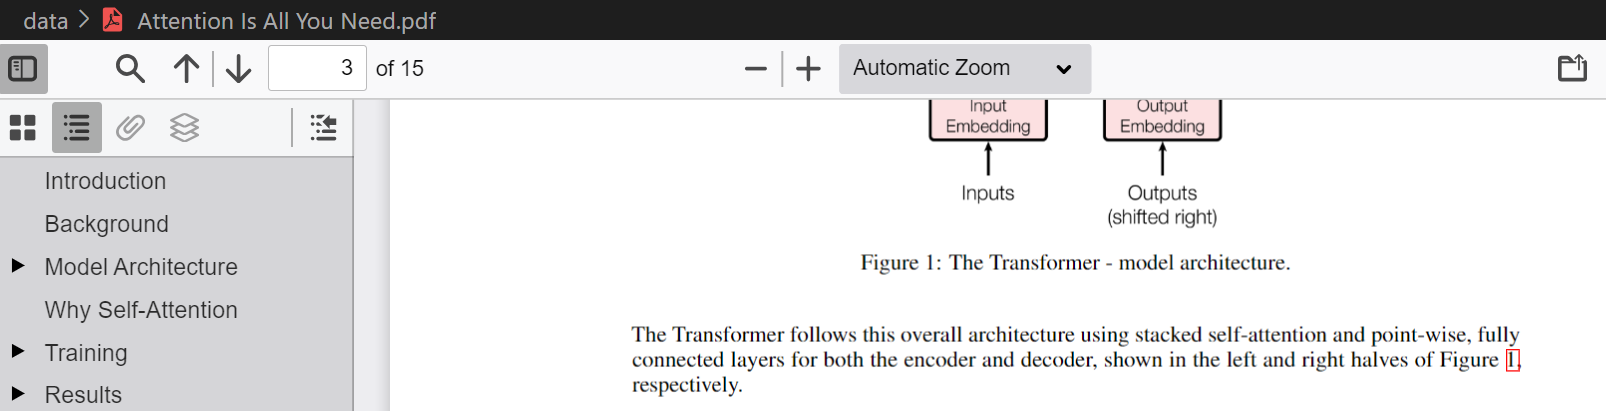